In [1]:
import pandas as pd
import matplotlib.pylab as plt

In [2]:
import tensorflow as tf

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
datagen = ImageDataGenerator(rescale=1./255)

In [5]:
train_generator = datagen.flow_from_directory("dataset/dataset/training_set",target_size=(64,64),class_mode="binary")

Found 7115 images belonging to 2 classes.


In [6]:
test_generator = datagen.flow_from_directory("dataset/dataset/test_set",target_size=(64,64),class_mode="binary")

Found 496 images belonging to 2 classes.


In [7]:
train_generator

In [8]:
data,label = next(train_generator)
data.shape

(32, 64, 64, 3)

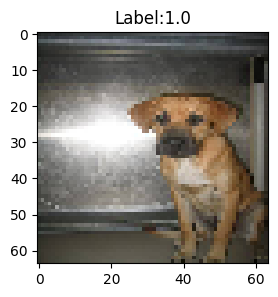

In [19]:
plt.figure(figsize=(3,3))
plt.imshow(data[23])  #from 32 images take first image
plt.title(f"Label:{label[23]}")   # take label of first image& show it as title of image
plt.show()

In [10]:
cnn = tf.keras.models.Sequential()
cnn.add(tf.keras.layers.Conv2D(filters = 32,kernel_size=3,activation="relu",input_shape=[64,64,3]))
cnn.add(tf.keras.layers.MaxPool2D(pool_size = 2,strides=2))
cnn.add(tf.keras.layers.Conv2D(filters = 32,kernel_size=3,activation="relu"))
cnn.add(tf.keras.layers.MaxPool2D(pool_size = 2,strides=2))
cnn.add(tf.keras.layers.Flatten())
cnn.add(tf.keras.layers.Dense(units=128,activation="relu"))
cnn.add(tf.keras.layers.Dense(units=1,activation="sigmoid"))   #output layers
    

C:\Users\Dipak\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
cnn.compile(optimizer = "adam",loss="binary_crossentropy",metrics=["accuracy"])

In [12]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 813,217 (3.10 MB)

 Trainable params: 813,217 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
result = cnn.fit(x = train_generator,epochs=1)

223/223 ━━━━━━━━━━━━━━━━━━━━ 49s 214ms/step - accuracy: 0.6117 - loss: 0.6488


In [14]:
cnn.evaluate(test_generator)

16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 380ms/step - accuracy: 0.7258 - loss: 0.5527


[0.5526766180992126, 0.725806474685669]

In [20]:
#predict a new data
import numpy as np
from keras.preprocessing import image
from keras.utils import load_img
from keras.utils import img_to_array
new_image = load_img('dataset/dataset/single_prediction/test.jpg', target_size = (64, 64))

#convert te image object to array
new_image = img_to_array(new_image)
new_image = np.expand_dims(new_image, axis = 0)
result = cnn.predict(new_image)
print(result)
# train_set.class_indices
if result[0][0]>=0.5:
  prediction = 'dog'
else:
  prediction = 'cat'
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
[[0.]]


'cat'